In [1]:
import pandas as pd
import numpy as np
import datetime
from scorepi import *
from epiweeks import Week
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import defaultdict
import seaborn as sns
import datetime
from datetime import datetime
from datetime import timedelta
from pathlib import Path
import matplotlib as mpl
import random
from numba import njit
from scipy.stats import linregress
import scipy.stats as stats
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

import warnings
warnings.filterwarnings('ignore')

In [2]:
from numba import njit
@njit
def energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum((X[i]-y)**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum((X[i]-X[j])**2))/(2*N**2)
    return ES


In [3]:
@njit
def normalized_energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum(((X[i]-y))**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum(((X[i]-X[j]))**2))/(2*N**2)
    return ES/sum(y)

In [4]:
import matplotlib.dates as mdates
def set_date_axis_fmt(ax):
    # Set the locator
    locator = mdates.MonthLocator()  # every month
    # Specify the format
    fmt = mdates.DateFormatter('%b %y')

    X = ax.xaxis
    X.set_major_locator(locator)
    # Specify formatter
    X.set_major_formatter(fmt)
    
    
def pull_surveillance_data():
    #flu surveillance data
    
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})



def pull_flu_scenario_modeling_hub_predictions(model,dates):
    """pull_scenario_modeling_hub_predictions. Load predictions of the model saved by the scenario modeling
    hub.

    Parameters
    ----------
    model : str
        Model name on thhe
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    if isinstance(dates,str):
        dates = [dates]
    for date in dates:
        url = f"https://raw.githubusercontent.com/midas-network/flu-scenario-modeling-hub/master/model-output/{model}/{date}-{model}"
        for ext in [".gz.parquet", ".parquet"]:
                try:
                    predictions = pd.read_parquet(url+ext)
                    
                except:
                    pass

    if predictions is None:
        print(f"Data for model {model} and date {dates} unavailable")
    return predictions



In [5]:
def format_observations(location, start_week = pd.to_datetime('2025-08-01') ):
    observations = pd.read_parquet(f"../fludat/truth_{'inc' if incidence else 'cum'}_{target_obs}.pq")
    observations['date'] = pd.to_datetime(observations['date'])

    #filter start - end week
    max_date = pd.to_datetime(observations.date.max())
    observations = observations[(observations['date'] >= start_week) & \
                                (observations['date'] <= max_date)]

    #filter location
    observations = observations[observations['location'] == location]

    #aggregate to weekly
    observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

    #transform to Observation object
    observations = Observations(observations)

    return observations

Pull surveillance data

In [6]:
target = 'hospitalization'
incidence=True
observations = pull_surveillance_data()
observations


,date,location,location_name,value,weekly_rate
0,2026-03-14,13,Georgia,124.0,1.109036
1,2026-03-14,18,Indiana,233.0,3.364973
2,2026-03-14,38,North Dakota,21.0,2.636310
3,2026-03-14,32,Nevada,50.0,1.530237
4,2026-03-14,36,New York,244.0,1.228152
...,...,...,...,...,...
11390,2022-02-05,51,Virginia,38.0,0.431270
11391,2022-02-05,29,Missouri,47.0,0.752546
11392,2022-02-05,55,Wisconsin,30.0,0.503273
11393,2022-02-05,10,Delaware,0.0,0.000000


In [125]:
# save surveillance data
#observations.to_parquet(f"../fludat/truth_{'inc' if incidence else 'cum'}_{target}.pq", index=False)

Pull Flu Scenario Modeling Hub data for all models

In [47]:
predictions

,origin_date,scenario_id,location,target,horizon,age_group,output_type,output_type_id,run_grouping,stochastic_run,value,Model
0,2025-08-10,A-2025-07-29,US,inc hosp,1,0-4,sample,NA,1,1,0.6769,UVA-FluXSim
1,2025-08-10,A-2025-07-29,US,inc hosp,1,0-4,sample,NA,2,1,0.6769,UVA-FluXSim
2,2025-08-10,A-2025-07-29,US,inc hosp,1,0-4,sample,NA,3,1,0.9126,UVA-FluXSim
3,2025-08-10,A-2025-07-29,US,inc hosp,1,0-4,sample,NA,4,1,0.6769,UVA-FluXSim
4,2025-08-10,A-2025-07-29,US,inc hosp,1,0-4,sample,NA,5,1,0.7372,UVA-FluXSim
...,...,...,...,...,...,...,...,...,...,...,...,...
12353095,2025-08-10,C-2025-07-29,56,inc hosp,43,0-130,sample,NA,296,1,0.0000,UVA-FluXSim
12353096,2025-08-10,C-2025-07-29,56,inc hosp,43,0-130,sample,NA,297,1,0.0000,UVA-FluXSim
12353097,2025-08-10,C-2025-07-29,56,inc hosp,43,0-130,sample,NA,298,1,0.0000,UVA-FluXSim
12353098,2025-08-10,C-2025-07-29,56,inc hosp,43,0-130,sample,NA,299,1,0.0000,UVA-FluXSim


In [18]:
models = ['ACCIDDA-FlepiMoP', 'CADPH-FluCAT', 'CEPH-MetaFlu', 'CFA-Scenarios', 'LEMMA-EnsembleDTWS',
          'MOBS_NEU-GLEAM_FLU', 'NIH-Flu_TS', 'OHT_JHU-gpop', 'PSI-M3', 'SigSci-SWIFT', 'UNCC-Hierbin',
          'UT-ImmunoSEIRS', 'UVA-FluXSim']
dates = ['2025-08-10']
rd = 6

for model in models:
    predictions = pull_flu_scenario_modeling_hub_predictions(model,dates)
    predictions['Model'] = model
    
    predictions = predictions[predictions['target'] =='inc hosp']


    numweeks = list(predictions.horizon.unique())

    start_date = list(predictions.origin_date.unique())[0]
    date_1 = pd.to_datetime(start_date)

    alldates = []
    for wk in numweeks:
        if wk==1:
            d = date_1 + timedelta(days=6*int(wk))
        else:
            d = date_1 + timedelta(days=6) + timedelta(weeks=int(wk-1))

        alldates.append(d)

    dfdates = pd.DataFrame({'horizon':numweeks, 'target_end_date':alldates})


    df = predictions.merge(dfdates, how='inner', on='horizon')


    df.to_parquet(f'../fludat/{model}_rd{rd}.pq', index=False)
    
    

In [19]:
# save into one dataframe

In [20]:
models = ['ACCIDDA-FlepiMoP', 'CADPH-FluCAT', 'CEPH-MetaFlu', 'CFA-Scenarios', 'LEMMA-EnsembleDTWS',
          'MOBS_NEU-GLEAM_FLU', 'NIH-Flu_TS', 'OHT_JHU-gpop', 'PSI-M3', 'SigSci-SWIFT', 'UNCC-Hierbin',
          'UT-ImmunoSEIRS', 'UVA-FluXSim']
dates = '2025-08-10'
rd = 6


In [21]:
predictionsall = pd.DataFrame()
for model in models:
    df = pd.read_parquet(f'../fludat/{model}_rd{rd}.pq')
    print(model, len(df.location.unique())) 
    
    predictionsall = pd.concat([predictionsall, df])

ACCIDDA-FlepiMoP 52
CADPH-FluCAT 1
CEPH-MetaFlu 52
CFA-Scenarios 1
LEMMA-EnsembleDTWS 52
MOBS_NEU-GLEAM_FLU 52
NIH-Flu_TS 51
OHT_JHU-gpop 1
PSI-M3 52
SigSci-SWIFT 48
UNCC-Hierbin 52
UT-ImmunoSEIRS 51
UVA-FluXSim 52


remove models with only one location

In [33]:
singleloc_models = ['CADPH-FluCAT', 'CFA-Scenarios', 'OHT_JHU-gpop', 'LEMMA-EnsembleDTWS']

predictionsall = predictionsall[~predictionsall['Model'].isin(singleloc_models)]

In [34]:
observations.date.max()

Timestamp('2026-03-14 00:00:00')

In [35]:
# filter by trajectories and only look at age group with all ages combined
predictions_traj = predictionsall[(predictionsall.output_type == 'sample') & \
                                   (predictionsall.age_group == '0-130')]
# filter by dates with data
predictions_traj = predictions_traj[predictions_traj.target_end_date <= pd.to_datetime(observations.date.max())]

In [43]:
predictions_traj[predictions_traj.Model=='UVA-FluXSim']

,origin_date,scenario_id,target,horizon,location,age_group,output_type,output_type_id,value,run_grouping,stochastic_run,Model,target_end_date
4500,2025-08-10,A-2025-07-29,inc hosp,1,US,0-130,sample,NA,27.7596,1,1,UVA-FluXSim,2025-08-16
4501,2025-08-10,A-2025-07-29,inc hosp,1,US,0-130,sample,NA,29.3213,2,1,UVA-FluXSim,2025-08-16
4502,2025-08-10,A-2025-07-29,inc hosp,1,US,0-130,sample,NA,27.9950,3,1,UVA-FluXSim,2025-08-16
4503,2025-08-10,A-2025-07-29,inc hosp,1,US,0-130,sample,NA,30.1655,4,1,UVA-FluXSim,2025-08-16
4504,2025-08-10,A-2025-07-29,inc hosp,1,US,0-130,sample,NA,28.4536,5,1,UVA-FluXSim,2025-08-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8704795,2025-08-10,C-2025-07-29,inc hosp,31,56,0-130,sample,NA,2.3937,296,1,UVA-FluXSim,2026-03-14
8704796,2025-08-10,C-2025-07-29,inc hosp,31,56,0-130,sample,NA,2.4789,297,1,UVA-FluXSim,2026-03-14
8704797,2025-08-10,C-2025-07-29,inc hosp,31,56,0-130,sample,NA,2.4029,298,1,UVA-FluXSim,2026-03-14
8704798,2025-08-10,C-2025-07-29,inc hosp,31,56,0-130,sample,NA,2.3891,299,1,UVA-FluXSim,2026-03-14


# Calculate scores

Calculate energy score for each model, scenario, and location

In [48]:
locations = pd.read_csv('../fludat/locations.csv',dtype={'location':str})
target_obs = 'hospitalization'
observations = pull_surveillance_data()
            
start_week = pd.to_datetime('2025-08-16')
max_date = pd.to_datetime(observations.date.max())


energyscoresdf = pd.DataFrame()


predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])

for model in predictions_traj.Model.unique():
    print(model)
    for loc in predictions_traj.location.unique():
        
        if loc in ['60','66','69', '72', '78']:
            continue
        
        for scenario in ['A', 'B', 'C']:
            
            target = 'hosp'
            incidence = True

            if target == 'hosp':
                target_obs = 'hospitalization'
            else:
                target_obs = target_obs
                

            observations = pull_surveillance_data()
            observations['date'] = pd.to_datetime(observations['date'])

            target_prediction_list = [f"{i} wk ahead {'inc' if incidence else 'cum'} {target}" for i in range(1,100)]

            predictionsfilt = predictions_traj[(predictions_traj.scenario_id == scenario + '-2025-07-29') & \
                                        (predictions_traj.location == loc) & \
                                        (predictions_traj.Model == model) & \
                                        (predictions_traj.target_end_date <= max_date) & \
                                        (predictions_traj.target_end_date >= start_week)]

            if len(predictionsfilt) == 0:
                print(f'no predictions for {model} at location {loc} for scenario {scenario}')
                continue
        
            observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            if model in [ 'NIH-Flu_TS']:
                X = [np.array(predictionsfilt[predictionsfilt['stochastic_run'] == i].value) for i in predictionsfilt['stochastic_run'].unique()]
            else:
                X = [np.array(predictionsfilt[predictionsfilt['run_grouping'] == i].value) for i in predictionsfilt['run_grouping'].unique()]

            ES = energyscore(np.array(X),y)
        

            if loc == 'US':
                loc_conv = loc
            elif int(loc) <10:
                loc_conv = loc[1]
            else:
                loc_conv = loc  

            newrow = pd.DataFrame({'Model':model,'Label': 'Scenario '+ scenario, 'location':loc_conv, 'energyscore':ES, 
                                'target':target}, index=[0])

            energyscoresdf = pd.concat([energyscoresdf, newrow])

energyscoresdf = energyscoresdf.reset_index()
energyscoresdf = energyscoresdf.drop(columns=['index'])   


energyscoresdf = pd.merge(energyscoresdf, locations, how = 'inner', on = 'location')



ACCIDDA-FlepiMoP
CEPH-MetaFlu
MOBS_NEU-GLEAM_FLU
NIH-Flu_TS
no predictions for NIH-Flu_TS at location 11 for scenario A
no predictions for NIH-Flu_TS at location 11 for scenario B
no predictions for NIH-Flu_TS at location 11 for scenario C
PSI-M3
SigSci-SWIFT
no predictions for SigSci-SWIFT at location 11 for scenario A
no predictions for SigSci-SWIFT at location 11 for scenario B
no predictions for SigSci-SWIFT at location 11 for scenario C
no predictions for SigSci-SWIFT at location 16 for scenario A
no predictions for SigSci-SWIFT at location 16 for scenario B
no predictions for SigSci-SWIFT at location 16 for scenario C
no predictions for SigSci-SWIFT at location 32 for scenario A
no predictions for SigSci-SWIFT at location 32 for scenario B
no predictions for SigSci-SWIFT at location 32 for scenario C
no predictions for SigSci-SWIFT at location 46 for scenario A
no predictions for SigSci-SWIFT at location 46 for scenario B
no predictions for SigSci-SWIFT at location 46 for scenari

In [51]:
energyscoresdf

,Model,Label,location,energyscore,target,abbreviation,location_name,population
0,ACCIDDA-FlepiMoP,Scenario A,1,444.147375,hosp,AL,Alabama,4903185
1,ACCIDDA-FlepiMoP,Scenario B,1,453.181347,hosp,AL,Alabama,4903185
2,ACCIDDA-FlepiMoP,Scenario C,1,512.864991,hosp,AL,Alabama,4903185
3,CEPH-MetaFlu,Scenario A,1,392.810367,hosp,AL,Alabama,4903185
4,CEPH-MetaFlu,Scenario B,1,585.747215,hosp,AL,Alabama,4903185
...,...,...,...,...,...,...,...,...
1381,UT-ImmunoSEIRS,Scenario B,US,63905.361935,hosp,US,US,328728466
1382,UT-ImmunoSEIRS,Scenario C,US,81075.474350,hosp,US,US,328728466
1383,UVA-FluXSim,Scenario A,US,53448.967496,hosp,US,US,328728466
1384,UVA-FluXSim,Scenario B,US,59339.770782,hosp,US,US,328728466


In [52]:
energyscoresdf.to_pickle("../fludat/energyscore_individual_rd6_fluhosp.pkl")

Calculate WIS from quantiles estimated from model trajectories for each model, scenario, and location averaged over the full influenza season

In [53]:
locations = pd.read_csv('../fludat/locations.csv',dtype={'location':str})
target_obs = 'hospitalization'
observations = pull_surveillance_data()
            
start_week = pd.to_datetime('2025-08-16')
max_date = pd.to_datetime(observations.date.max())

modelsall = ['ACCIDDA-FlepiMoP', 'CEPH-MetaFlu', 'MOBS_NEU-GLEAM_FLU', 'NIH-Flu_TS',  'PSI-M3', 'SigSci-SWIFT', 
             'UNCC-Hierbin','UT-ImmunoSEIRS', 'UVA-FluXSim']


wisdf_traj = pd.DataFrame()

predictionsall = pd.DataFrame()
i=0
for model in modelsall:
    df = pd.read_parquet(f'../fludat/{model}_rd6.pq')
    # filter by trajectories and only look at age group with all ages combined
    df = df[(df.output_type == 'sample') & (df.age_group == '0-130')]
    
    df['Model'] = model
    df['trajectory_id'] = df.groupby(['stochastic_run', 'run_grouping', 'location']).ngroup()
    predictionsall = pd.concat([predictionsall, df])
    i += 1
    

loclist = list(predictionsall.location.unique())
for model in modelsall:

    for loc in loclist:
    
        if loc in ['60','66','69', '72', '78']:
            continue
            
        for scenario in ['A', 'B', 'C']:
            location = loc
            target = 'hosp'
            incidence = True

            if target == 'hosp':
                target_obs = 'hospitalization'
            else:
                target_obs = target_obs

            predictionsfilt = predictionsall[(predictionsall.scenario_id == scenario + '-2025-07-29') & \
                                        (predictionsall.location == location) & \
                                        (predictionsall.target == 'inc ' + target)  & \
                                        (predictionsall.target_end_date <= max_date) & \
                                        (predictionsall.target_end_date >= start_week) &\
                                        (predictionsall.Model == model)]

            if len(predictionsfilt)==0:
                continue
            
            observations = pull_surveillance_data()
            observations['date'] = pd.to_datetime(observations['date'])
            
            observations = observations[(observations['date'] >= start_week) & \
                                        (observations['date'] <= max_date)]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            X = np.array([np.array(predictionsfilt[predictionsfilt.trajectory_id == i].value) \
                            for i in predictionsfilt.trajectory_id.unique()])

            quantiles=[0.01,0.025,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.60,
                        0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.975,0.99]

            # get quantiles
            Q = np.quantile(X,quantiles,axis=0)

            # calculate WIS
            WIS = np.zeros(X.shape[1])
            
            for i in range(len(quantiles) // 2):
                interval_range = 100*(quantiles[-i-1]-quantiles[i])
                alpha = 1-(quantiles[-i-1]-quantiles[i])
                IS = interval_score(y,Q[i],Q[-i-1],interval_range)
                WIS += IS['interval_score']*alpha/2
            WIS += 0.5*np.abs(Q[len(quantiles) // 2] - y)

            WIS = np.mean(WIS) / (len(quantiles) // 2 + 0.5)

            if loc == 'US':
                loc_conv = loc
            elif int(loc) <10:
                loc_conv = loc[1]
            else:
                loc_conv = loc  

            # save into dataframe
            newrow = pd.DataFrame({'Model':model , 'Label': 'Scenario '+ scenario, 'location':loc_conv, 'WIS':WIS, 
                                'target':target}, index=[0])

            wisdf_traj = pd.concat([wisdf_traj, newrow])



wisdf_traj = wisdf_traj.reset_index()
wisdf_traj = wisdf_traj.drop(columns=['index'])   


wisdf_traj = pd.merge(wisdf_traj, locations, how = 'inner', on = 'location')


#samplewisdf.to_pickle(f'./samplewis/wis_ensemble_rd17_hosp_trajectory.pkl')



In [55]:
wisdf_traj.to_pickle("../fludat/wis_trajectory_indiv_flu_rd6_hosp.pkl")

In [54]:
wisdf_traj

,Model,Label,location,WIS,target,abbreviation,location_name,population
0,ACCIDDA-FlepiMoP,Scenario A,1,48.806023,hosp,AL,Alabama,4903185
1,ACCIDDA-FlepiMoP,Scenario B,1,49.717647,hosp,AL,Alabama,4903185
2,ACCIDDA-FlepiMoP,Scenario C,1,54.669386,hosp,AL,Alabama,4903185
3,CEPH-MetaFlu,Scenario A,1,40.451293,hosp,AL,Alabama,4903185
4,CEPH-MetaFlu,Scenario B,1,56.295182,hosp,AL,Alabama,4903185
...,...,...,...,...,...,...,...,...
1381,UT-ImmunoSEIRS,Scenario B,US,6797.989125,hosp,US,US,328728466
1382,UT-ImmunoSEIRS,Scenario C,US,8430.237751,hosp,US,US,328728466
1383,UVA-FluXSim,Scenario A,US,5887.573751,hosp,US,US,328728466
1384,UVA-FluXSim,Scenario B,US,6498.459797,hosp,US,US,328728466


# Analysis

plots comparing energy score and WIS values

In [56]:
models = ['ACCIDDA-FlepiMoP', 'CEPH-MetaFlu', 'MOBS_NEU-GLEAM_FLU', 'NIH-Flu_TS',  'PSI-M3', 'SigSci-SWIFT', 
             'UNCC-Hierbin','UT-ImmunoSEIRS', 'UVA-FluXSim']

modelmap = {'MOBS_NEU-GLEAM_FLU':'Model A', 'NIH-Flu_TS': 'Model B',
            'PSI-M3':'Model C',  'UT-ImmunoSEIRS':'Model D', 'ACCIDDA-FlepiMoP': 'Model E', 
            'CEPH-MetaFlu': 'Model F', 'SigSci-SWIFT': 'Model G', 'UNCC-Hierbin': 'Model H', 'UVA-FluXSim':'Model I'}

3.138923188258517e-134


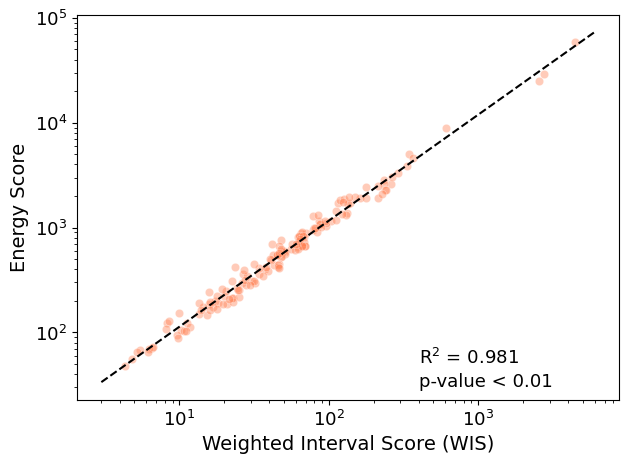

In [57]:
fig, axes = plt.subplots(figsize=(7,5))
rd = 6
es = pd.read_pickle("../fludat/energyscore_individual_rd6_fluhosp.pkl")

wisdf = pd.read_pickle("../fludat/wis_trajectory_indiv_flu_rd6_hosp.pkl")

cmap = plt.get_cmap('Set2', 10)
colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

es =es[es.Model=='MOBS_NEU-GLEAM_FLU']
wisdf =  wisdf[wisdf.Model == 'MOBS_NEU-GLEAM_FLU']
    
allscores = es.merge(wisdf, on=['location', 'Label','Model']).dropna()
allscores['modelmap'] = allscores['Model'].apply(lambda x: modelmap[x])
allscores = allscores.sort_values(by='modelmap')

sns.scatterplot(data=allscores, x='WIS', y='energyscore', color='coral', alpha=.4)

slope, intercept, r_value, p_value, std_err = linregress(allscores.WIS, allscores.energyscore,
                                                        alternative='two-sided')

logslope, logintercept, logr_value, logp_value, logstd_err = linregress(np.log10(allscores.WIS), 
                                                                        np.log10(allscores.energyscore),
                                                                       alternative='two-sided')
print(p_value)

xval = np.linspace(3, 6000, 100)
yval = 10**(logslope*np.log10(xval)+logintercept)

plt.plot(xval, yval, '--',color='k')


plt.text(400,50, r'R$^2$ = '+str(round(r_value**2, 3)), fontsize=13)
plt.text(400,30, r'p-value < 0.01', fontsize=13)


plt.xlabel('Weighted Interval Score (WIS)', fontsize=14)
plt.ylabel('Energy Score', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xscale("log")
plt.yscale("log")

#plt.savefig('../figs/ESvsWIS_MOBS_1115.pdf')
plt.show()

In [111]:
p_value

0.0

# Compare SMH projections with baseline model for all models

In [13]:
# download baseline model energy score 

baseline = pd.read_pickle('../fludat/flu-baseline_energyscore_118.pkl').rename(columns={'energyscore':'energyscore_baseline',
                                                                           'Model':'baseline_model'})

energyscoresdf = pd.read_pickle("../fludat/energyscore_individual_rd4_hosp_521.pkl")
energyscoresdf['target'] = 'inc hosp'
energyscoresdf['location'] = energyscoresdf['location'].apply(lambda x: '0'+x if len(x)<2 else x)


# calculate energy score ratio
ES_ratiodf = energyscoresdf.merge(baseline, on = ['location', 'target'])
ES_ratiodf['ES_ratio'] = ES_ratiodf['energyscore'] / ES_ratiodf['energyscore_baseline']

In [14]:
models = ['MOBS_NEU-GLEAM_FLU', 'NIH-Flu_TS', 'NotreDame-FRED', 'PSI-M2', 'USC-SIkJalpha',
          'UT-ImmunoSEIRS']

modelmap = {'MOBS_NEU-GLEAM_FLU':'Model I', 'NIH-Flu_TS': 'Model II','NotreDame-FRED':'Model III',
            'PSI-M2':'Model IV', 'USC-SIkJalpha':'Model V', 'UT-ImmunoSEIRS':'Model VI',
            'Trajectory Ensemble': 'Trajectory Ensemble'}

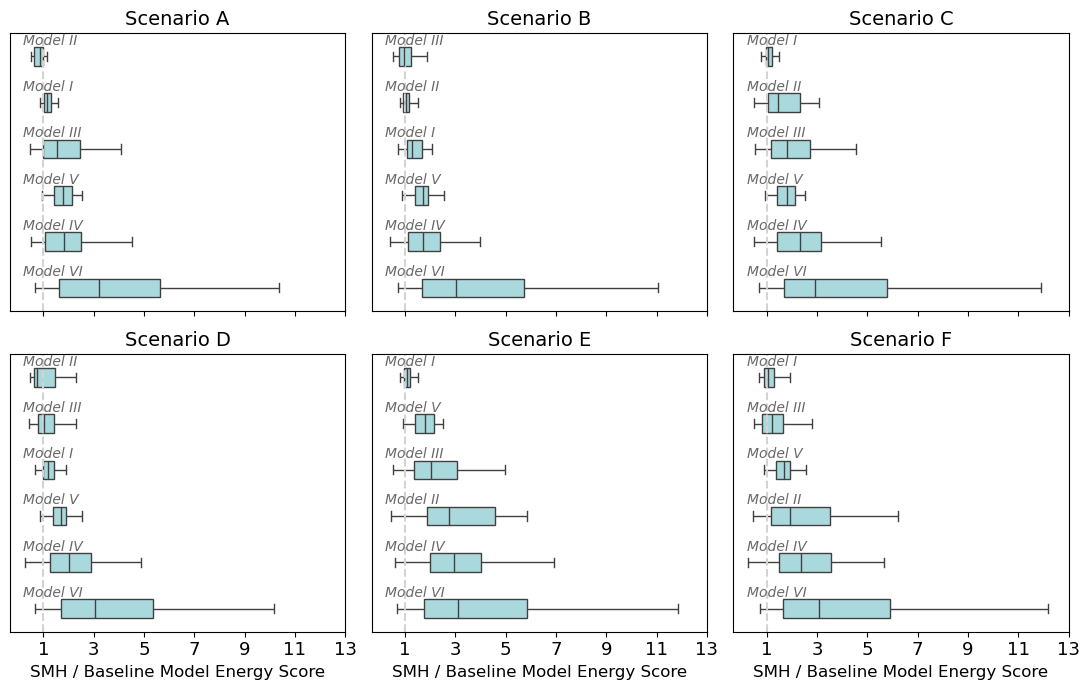

In [15]:
fig, ax = plt.subplots(2,3,figsize=(11,7), sharex=True)
#plt.subplots_adjust(hspace=4)
i=1
for scenario in ES_ratiodf.Label.unique():
    plt.subplot(2,3,i)
    
    if i<4:
        x = 0
    else:
        x=1

        
    if i in [1,4]:
        y=0
    elif i in [2,5]:
        y=1
    else:
        y=2
    
    rankinfo = ES_ratiodf[ES_ratiodf.Label == scenario]
    
    
    my_order = rankinfo.groupby(by=["Model"])["ES_ratio"].median().sort_values(ascending=True).index
    
    g = sns.boxplot(x='ES_ratio', y='Model', data=rankinfo, order = my_order, color = '#17B1BF', width=0.4,
                   showfliers=False)
    
    g.set(yticklabels=[])
    g.set(yticks=[])
        
    if i in [1, 4]:
        plt.ylabel('', fontsize=15)
    else:
        g.set(ylabel=None)    
        
    if i in [4,5,6]:
        plt.xlabel('SMH / Baseline Model Energy Score', fontsize=12)
    else:
        g.set(xlabel=None)

    i+=1 
    plt.title(scenario, fontsize=14)
   # plt.xlim([0, 2.5])
    
    
    for patch in ax[x][y].patches:
        r, gr, b, a = patch.get_facecolor()
        patch.set_facecolor((r, gr, b, .4))

    
    plt.axvline(x=1, ymin=0, ymax=3,linestyle='--', color = 'lightgray', alpha=1)

    
    a = 0
    for mod in list(my_order):
        plt.text(0.2,a-.25, modelmap[mod], fontsize=10, style='italic', color='dimgray')
        a+=1
    
    plt.xticks([1,3,5,7,9,11,13],fontsize=13)
plt.tight_layout()
plt.savefig('../figs/ESratio_flurd4_models_h_0530_new.pdf')
plt.show()


In [10]:
ES_ratiodf['Model'] = ES_ratiodf['Model'].apply(lambda x: modelmap[x])

df = ES_ratiodf.groupby(['Label', 'Model']).ES_ratio.describe(percentiles=[.05,.5,.95]).drop(columns=['mean',
                                                         'std']).round(2)

In [11]:
df.to_latex()

'\\begin{tabular}{llrrrrrr}\n\\toprule\n           &          &  count &   min &    5\\% &   50\\% &    95\\% &    max \\\\\nLabel & Model &        &       &       &       &        &        \\\\\n\\midrule\nScenario A & Model I &   52.0 &  0.87 &  0.91 &  1.16 &   1.49 &   1.59 \\\\\n           & Model II &   13.0 &  0.50 &  0.50 &  0.84 &   1.13 &   1.13 \\\\\n           & Model III &   52.0 &  0.48 &  0.60 &  1.55 &   3.40 &   7.04 \\\\\n           & Model IV &   52.0 &  0.51 &  0.65 &  1.80 &   4.90 &   7.48 \\\\\n           & Model V &   52.0 &  0.93 &  1.09 &  1.79 &   2.52 &   4.70 \\\\\n           & Model VI &   51.0 &  0.66 &  0.87 &  3.19 &  12.22 &  16.66 \\\\\nScenario B & Model I &   52.0 &  0.73 &  0.84 &  1.29 &   1.87 &   2.07 \\\\\n           & Model II &   13.0 &  0.79 &  0.81 &  1.02 &   1.55 &   1.61 \\\\\n           & Model III &   52.0 &  0.51 &  0.56 &  0.94 &   2.59 &   4.49 \\\\\n           & Model IV &   52.0 &  0.39 &  0.51 &  1.71 &   3.78 &   4.73 \\\\\n    

# Rankings

In [70]:
# energy score rank

es_all = pd.read_pickle("../fludat/energyscore_individual_rd6_fluhosp.pkl")


# standardized rank energy score

dfrankall = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank','target'])

dfa =  es_all.copy()

dfrank = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank', 'target'])

states = list(dfa.location.unique())

for state in states:
    for scenario in dfa.Label.unique():
        filt = dfa[(dfa['location']==state) & (dfa.Label == scenario)]
        filt = filt.sort_values('energyscore')

        rank = list(filt.Model)
        for model in rank:
            rankval = rank.index(model)+1

            new_row = {'Model':model, 'location': state, 'Standard_Rank': rankval, 'target':target,  
                      'Label':scenario}

            dfrank = dfrank.append(new_row, ignore_index=True)

dfrankall = pd.concat([dfrankall, dfrank])
dfrankallenergyscore = dfrankall.reset_index()
dfrankallenergyscore = dfrankallenergyscore.drop(columns=['index']).rename(columns={'Standard_Rank':'standard_rank_ES'})


In [71]:
# wis rank

dfa = pd.read_pickle("../fludat/wis_trajectory_indiv_flu_rd6_hosp.pkl")

dfrank = pd.DataFrame(columns=['Model', 'location', 'Standard_Rank', 'target'])

states = list(dfa.location.unique())

for state in states:
    for scenario in dfa.Label.unique():
        filt = dfa[(dfa['location']==state) & (dfa.Label == scenario)]
        filt = filt.sort_values('WIS')

        rank = list(filt.Model)
        for model in rank:
            rankval = rank.index(model)+1

            new_row = {'Model':model, 'location': state, 'Standard_Rank': rankval, 'target':target,  
                      'Label':scenario}

            dfrank = dfrank.append(new_row, ignore_index=True)


dfrankallwis = dfrank.reset_index()
dfrankallwis = dfrankallwis.drop(columns=['index']).rename(columns={'Standard_Rank':'standard_rank_wis'})


In [72]:
dfrankall = dfrankallenergyscore.merge(dfrankallwis, on = ['Model', 'location', 'Label', 'target'])

In [73]:
# calculate kendall tau rank correlation for energy score and WIS
ranks = pd.DataFrame()
for loc in dfrankall.location.unique():
    for scenario in dfrankall.Label.unique():

        df = dfrankall[(dfrankall.location==loc) & (dfrankall.Label==scenario)]
        tau, pval = stats.kendalltau(df.standard_rank_wis, df.standard_rank_ES)
        
        row = pd.DataFrame({'location':loc, 'Label':scenario, 'tau':tau}, index=[0])
        
        ranks = pd.concat([ranks, row])

In [74]:
ranks.mean()  

tau    0.777116
dtype: float64

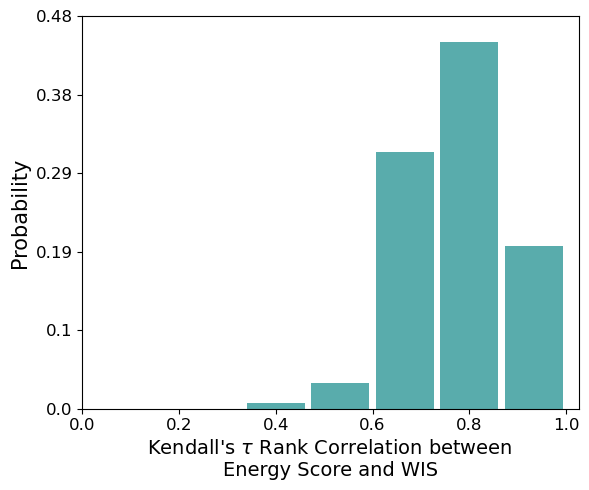

In [88]:
plt.figure(figsize=(6,5))
plt.hist(ranks.tau,bins=5,color='teal', rwidth=.9, alpha=.65, align='mid')
plt.xlabel('Kendall\'s'+ r' $\tau$ Rank Correlation'+ ' between \nEnergy Score and WIS', fontsize=14)
plt.ylabel('Probability', fontsize=15)
plt.xticks([0, .2, .4, .6, .8, 1.0], fontsize=12)
plt.yticks([0,15,30,45,60,75],fontsize=12, labels = [round(i/len(ranks),2) for i in [0,15,30,45,60,75]])
#plt.yticklabel([i/len(ranks) for i in [0,50,100,150,200]],fontsize=12)

plt.tight_layout()
#plt.savefig('../figs/kendalltau_histogram_rank_D_updated_0626.pdf')

In [80]:
(len(ranks[ranks.tau>.99])/len(ranks))*100

1.9230769230769231

In [84]:
dfrankallenergyscore.Model.unique()

array(['MOBS_NEU-GLEAM_FLU', 'CEPH-MetaFlu', 'NIH-Flu_TS',
       'ACCIDDA-FlepiMoP', 'SigSci-SWIFT', 'PSI-M3', 'UNCC-Hierbin',
       'UT-ImmunoSEIRS', 'UVA-FluXSim'], dtype=object)

[0.33333333 0.46666667 0.6        0.73333333 0.86666667 1.        ]


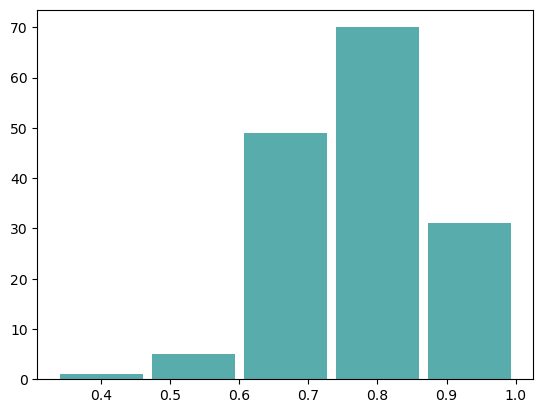

In [86]:
counts, bin_edges, patches = plt.hist(ranks.tau, bins=5, color='teal', rwidth=.9, alpha=.65, align='mid')
print(bin_edges)